**IMPORTS**

In [131]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import kagglehub
import random

# Setting a seed to get the same accuracy results every time
seed_value = 33

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [132]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


**LOADING DATA**

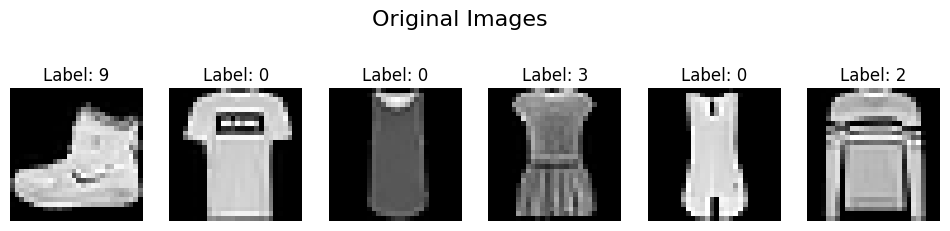

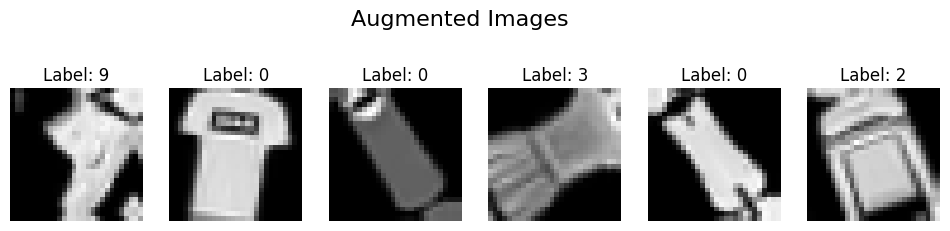

In [133]:
DATA_PATH = path

# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels
try:
    # Load training data
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    # Load test data
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()

# Define class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Adding some data augmentation to increase the training dataset
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=seed_value),
    tf.keras.layers.RandomRotation(0.2, seed=seed_value),
    tf.keras.layers.RandomZoom(0.2, seed=seed_value)
])

# Step 3: Preprocess the Data, normilize pixel data from 0~255 to 0~1.0
train_images = train_images / 255.0
test_images = test_images / 255.0

augmented_images = augmenter(train_images[..., None])  #  Keras data augmentation expects a channel dimension (1 because it's grayscale)
augmented_images = tf.squeeze(augmented_images).numpy()  # remove channel dimension


# Concatenate with original data
train_images_expanded = np.concatenate([train_images, augmented_images], axis=0)
train_labels_expanded = np.concatenate([train_labels, train_labels], axis=0)

def show_samples(images, labels, title, num=6):
    plt.figure(figsize=(12, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.show()

# Original images
show_samples(train_images, train_labels, "Original Images")

# Augmented images
show_samples(augmented_images, train_labels, "Augmented Images")




# 新段落

**MODEL**

In [134]:
# Step 4: Build the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(124, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display a summary of the model's architecture
print("Model Summary:")
model.summary()

Model Summary:


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_18 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 10)             │         1,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,078 (914.37 KB)

 Trainable params: 234,078 (914.37 KB)

 Non-trainable params: 0 (0.00 B)

**TRAINING**

In [135]:
# Step 6: Train the Model
print("\nStarting model training...")
history = model.fit(train_images_expanded, train_labels_expanded, epochs=15, validation_split=0.1)
print("Model training finished.")



Starting model training...
Epoch 1/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7241 - loss: 0.7703 - val_accuracy: 0.7552 - val_loss: 0.6621
Epoch 2/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8215 - loss: 0.4818 - val_accuracy: 0.7740 - val_loss: 0.6058
Epoch 3/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8413 - loss: 0.4277 - val_accuracy: 0.7922 - val_loss: 0.5537
Epoch 4/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8532 - loss: 0.3925 - val_accuracy: 0.8034 - val_loss: 0.5316
Epoch 5/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8616 - loss: 0.3666 - val_accuracy: 0.8066 - val_loss: 0.5235
Epoch 6/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8686 - loss: 0.3464 - val_accuracy: 0.8085 - val_loss: 0.5340
Epoch 7/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8747 - loss: 0.3292 - val_accuracy: 0.8085 - val_loss: 0.5307
Epoch 8/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accu

**PLOTTING HELPER FUNCS**

In [136]:
# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

**TESTING**


Evaluating model on test data...
313/313 - 1s - 5ms/step - accuracy: 0.8821 - loss: 0.3966

Test accuracy: 0.8821
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Visualizing a prediction...


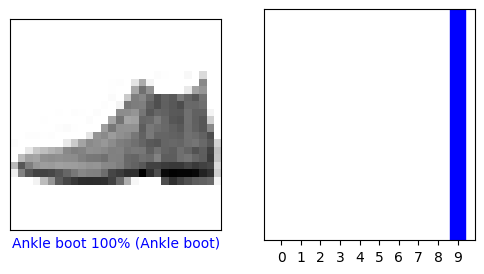


Plotting training history...


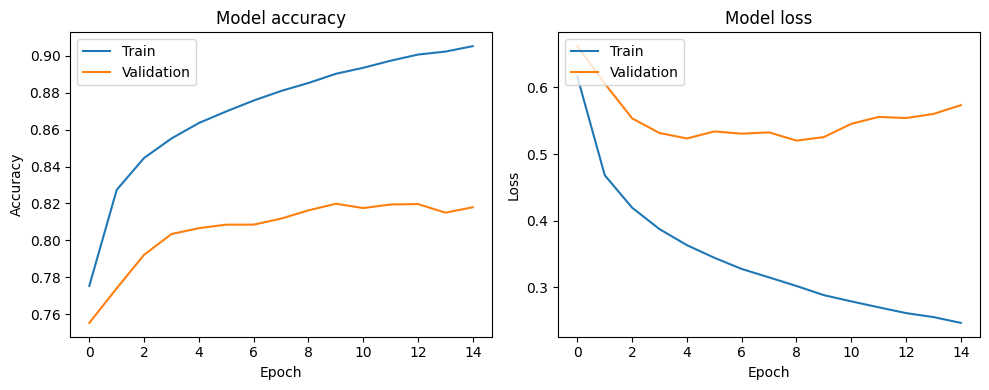

In [137]:
# Step 7: Evaluate the Model's Accuracy
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Step 8: Make Predictions
predictions = model.predict(test_images)


# Let's visualize the prediction for the first image
print("\nVisualizing a prediction...")
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()